## 2ª pre-entrega 

Integrantes: Erica Blanco, Francesca Matias. 


TEMA ELEGIDO: churn 
Pregunta que esperamos responder es: 
Podemos predecir si un cliente va a abandonar el banco (exited) a partir de sus datos demográficos y de cuenta?

## Diagnóstico inicial

Antes de explorar el dataset en profundidad, veamos su estructura general, es decir cantidad de
filas y columnas, tipos de dato, y si hay valores duplicados o columnas que no aportan información.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Churn_Modelling.csv") 

In [4]:
renombrar = {
    'CreditScore': 'credit_score',
    'Geography': 'geography',
    'Gender': 'gender',
    'Age': 'age',
    'Tenure': 'tenure',
    'Balance': 'balance',
    'NumOfProducts': 'num_of_products',
    'HasCrCard': 'has_cr_card',
    'IsActiveMember': 'is_active_member',
    'EstimatedSalary': 'estimated_salary',
    'Exited': 'exited'
}

df = df.rename(columns=renombrar)

In [5]:
#validamos que este bien cargado el dataset
df.head()

,RowNumber,CustomerId,Surname,credit_score,geography,gender,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   RowNumber         10000 non-null  int64  
 1   CustomerId        10000 non-null  int64  
 2   Surname           10000 non-null  str    
 3   credit_score      10000 non-null  int64  
 4   geography         10000 non-null  str    
 5   gender            10000 non-null  str    
 6   age               10000 non-null  int64  
 7   tenure            10000 non-null  int64  
 8   balance           10000 non-null  float64
 9   num_of_products   10000 non-null  int64  
 10  has_cr_card       10000 non-null  int64  
 11  is_active_member  10000 non-null  int64  
 12  estimated_salary  10000 non-null  float64
 13  exited            10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [7]:
df.describe()

,RowNumber,CustomerId,credit_score,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
#el nunique nos permite ver la cantidad de valores unicos por columna, lo cual nos permite ver si hay columnas que  no aportan valor al dataset
df.nunique()

RowNumber           10000
CustomerId          10000
Surname              2932
credit_score          460
geography               3
gender                  2
age                    70
tenure                 11
balance              6382
num_of_products         4
has_cr_card             2
is_active_member        2
estimated_salary     9999
exited                  2
dtype: int64

RowNumber y CustomerId tienen 10.000 valores únicos, y Surname tiene 2.932 sobre 10.000 filas, son identificadores, no información predictiva, así que muy probablemente se descarten del dataset final.

In [10]:
#Bandera binaria 1 si el cliente cerró la cuenta con el banco y 0 si el cliente es retenido
df['exited'].value_counts()

exited
0    7963
1    2037
Name: count, dtype: int64

## Análisis de exited

exited es nuestra variable objetivo: 1 si el cliente cerró la cuenta, 0 si sigue siendo cliente. Revisamos primero qué tan balanceadas están las dos clases, porque eso condiciona cómo vamos a evaluar el modelo.

In [11]:
#Bandera binaria 1 si el cliente cerró la cuenta con el banco y 0 si el cliente es retenido
df['exited'].value_counts(normalize=True)

exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

In [12]:
#valores faltantes 
df.isna().sum()

RowNumber           0
CustomerId          0
Surname             0
credit_score        0
geography           0
gender              0
age                 0
tenure              0
balance             0
num_of_products     0
has_cr_card         0
is_active_member    0
estimated_salary    0
exited              0
dtype: int64

In [13]:
# se puede ver que no tenemos valores faltantes, pero si queremos ver el porcentaje de valores faltantes por columna 
# podemos hacer lo siguiente:
(df.isna().sum() / len(df)) * 100

RowNumber           0.0
CustomerId          0.0
Surname             0.0
credit_score        0.0
geography           0.0
gender              0.0
age                 0.0
tenure              0.0
balance             0.0
num_of_products     0.0
has_cr_card         0.0
is_active_member    0.0
estimated_salary    0.0
exited              0.0
dtype: float64

## Variables numéricas

Miramos las estadísticas descriptivas de las variables numéricas para detectar rangos razonables y posibles distribuciones inusuales.

In [14]:
#Analizamos las cateogrias numericas 
df[['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']].describe()

,credit_score,age,tenure,balance,estimated_salary
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,100090.239881
std,96.653299,10.487806,2.892174,62397.405202,57510.492818
min,350.000000,18.000000,0.000000,0.000000,11.580000
25%,584.000000,32.000000,3.000000,0.000000,51002.110000
50%,652.000000,37.000000,5.000000,97198.540000,100193.915000
75%,718.000000,44.000000,7.000000,127644.240000,149388.247500
max,850.000000,92.000000,10.000000,250898.090000,199992.480000


Balance llama la atención: el percentil 25 es 0, pero la mediana es ~97.198. Esto sugiere una distribución bimodal, es decir un grupo grande de clientes con saldo en cero y otro grupo con saldos altos.

## Variables categóricas

Revisamos la distribución de las variables categóricas antes de cruzarlas con el target.

In [15]:
df['geography'].value_counts()

geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [16]:
df['num_of_products'].value_counts()

num_of_products
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

Geography está desbalanceada (Francia tiene el doble de clientes que Alemania o España).
NumOfProducts también, la gran mayoría tiene 1 o 2 productos, mientras que 3 y 4 productos son casi anecdóticos (266 y 60 casos)


Buscamos outliers en las variables numericas, para esto vamos a usar boxplots

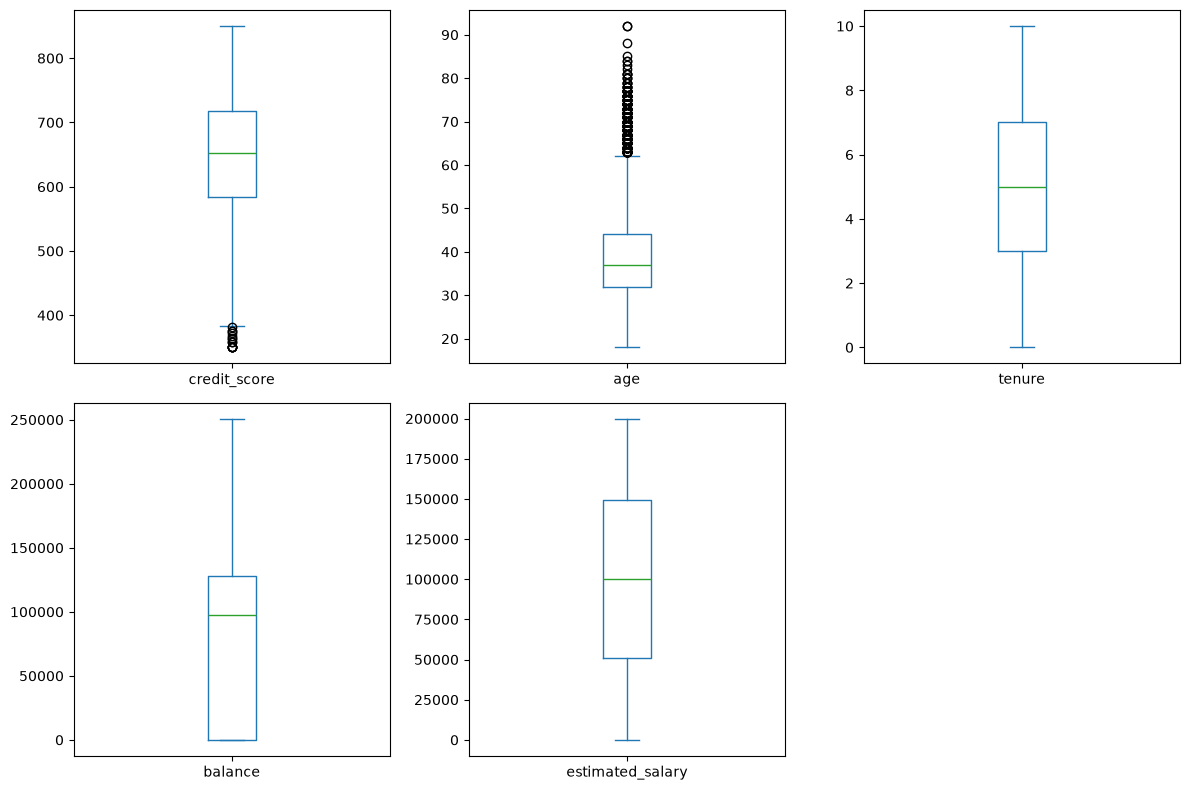

In [17]:
df[['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']].plot(
    kind='box', subplots=True, layout=(2,3), figsize=(12,8)
)
plt.tight_layout()
plt.show()

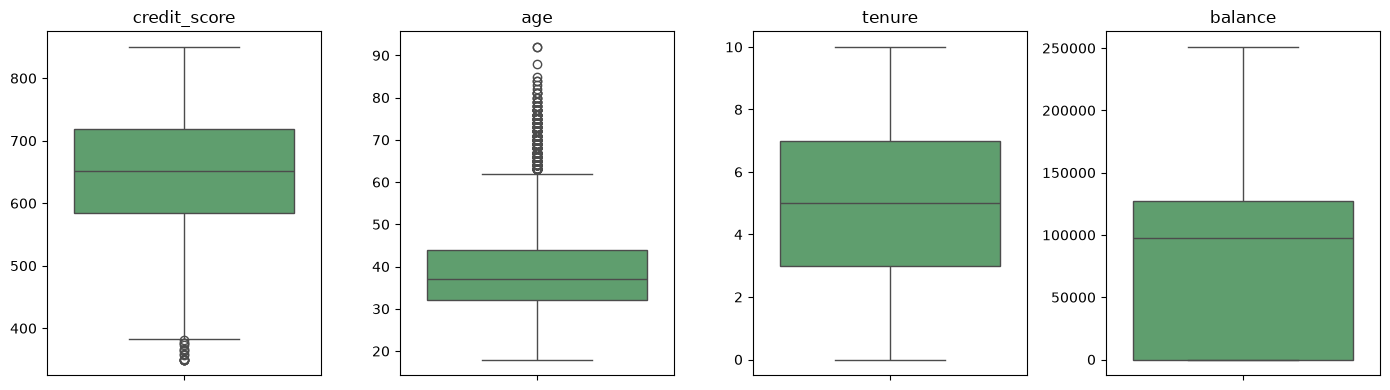

In [18]:
variables = df[['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for eje, variable in zip(axes, variables):
    sns.boxplot(y=df[variable], ax=eje, color="#55A868")
    eje.set_title(variable)
    eje.set_ylabel("")
plt.tight_layout()
plt.show()

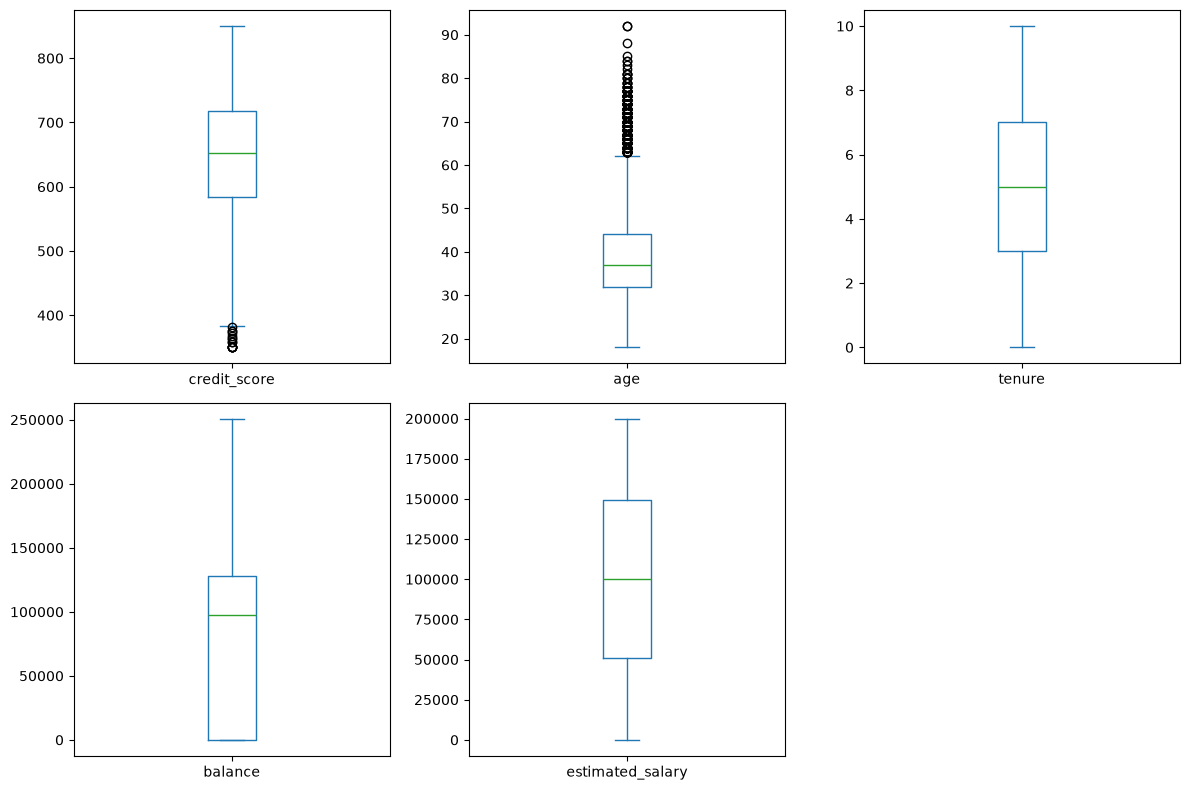

In [19]:
df[['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']].plot(
    kind='box', subplots=True, layout=(2,3), figsize=(12,8)
)
plt.tight_layout()
plt.show()

# se pueden ver outliers estadisticos pero no errores de datos, ya que puede pasar que una persona tenga score de credito bajo 
# y que una persona de 80 a 90 años sea cliente del banco, por lo que no vamos a eliminar outliers de nuestro dataset.

## Cruce de variables numéricas contra el target

Ahora comparamos cada variable numérica entre los dos grupos (se quedó vs. se fue) para ver si hay diferencias que puedan servir como predictoras.

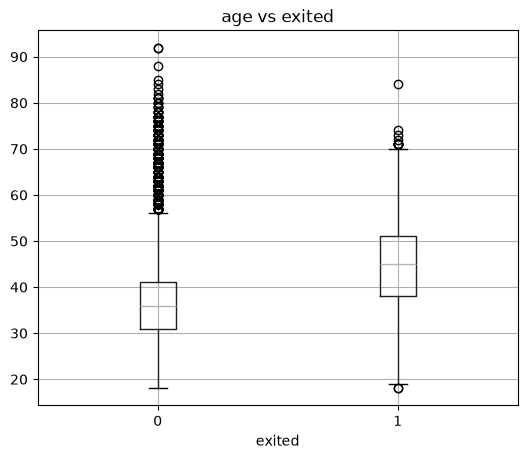

In [20]:
df.boxplot(column='age', by='exited', figsize=(6,5))
plt.title('age vs exited')
plt.suptitle('')
plt.show()

In [21]:
df.groupby('exited')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
exited,,,,,,,,
0,7963.0,37.408389,10.125363,18.0,31.0,36.0,41.0,92.0
1,2037.0,44.837997,9.761562,18.0,38.0,45.0,51.0,84.0


Se puede ver que la media de edad de los clientes que cerraron la cuenta es mayor a la media de edad de los clientes que no cerraron la cuenta, por lo que podemos decir que la edad es un factor importante a la hora de predecir si un cliente va a cerrar su cuenta o no. 

In [22]:
df.groupby('exited')['balance'].describe()

,count,mean,std,min,25%,50%,75%,max
exited,,,,,,,,
0,7963.0,72745.296779,62848.040701,0.0,0.00,92072.68,126410.28,221532.80
1,2037.0,91108.539337,58360.794816,0.0,38340.02,109349.29,131433.33,250898.09


se puede ver que los clientes con saldo en su cuenta tienen una mayor probabilidad de cerrar su cuenta, por lo que podemos decir que el saldo es un factor importante a la hora de predecir si un cliente va a cerrar su cuenta o no.

In [23]:
(df.groupby('exited')['balance'].apply(lambda x: (x == 0).mean()) * 100)

exited
0    39.143539
1    24.545901
Name: balance, dtype: float64

Ahora vamos a analizar las variables categóricas 

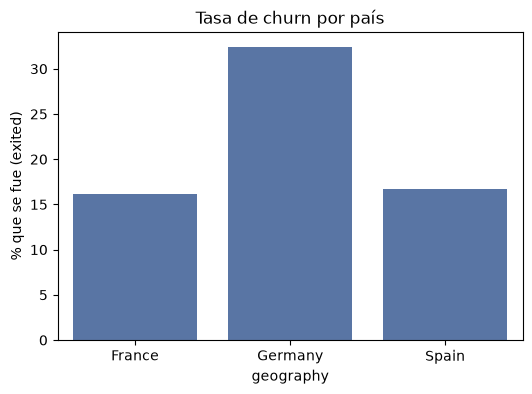

In [24]:
tasa_por_geografia = df.groupby('geography')['exited'].mean() * 100

plt.figure(figsize=(6, 4))
sns.barplot(x=tasa_por_geografia.index, y=tasa_por_geografia.values, color="#4C72B0")
plt.ylabel('% que se fue (exited)')
plt.title('Tasa de churn por país')
plt.show()

se puede ver que los clientes de alemania tienen una mayor probabilidad de cerrar su cuenta

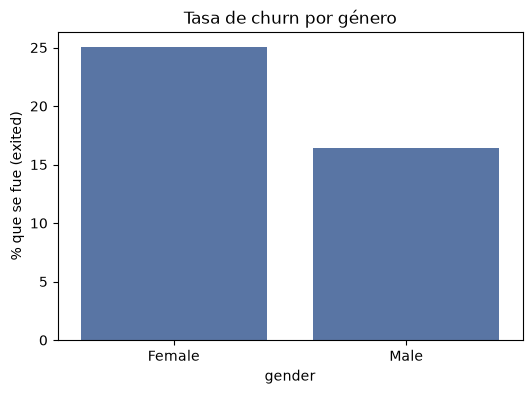

In [25]:
tasa_por_genero = df.groupby('gender')['exited'].mean() * 100

plt.figure(figsize=(6, 4))
sns.barplot(x=tasa_por_genero.index, y=tasa_por_genero.values, color="#4C72B0")
plt.ylabel('% que se fue (exited)')
plt.title('Tasa de churn por género')
plt.show()


En este caso se puede ver que la mujere se van mas que los hombres, pero la diferencia no es tan grande como en el caso de la geografia

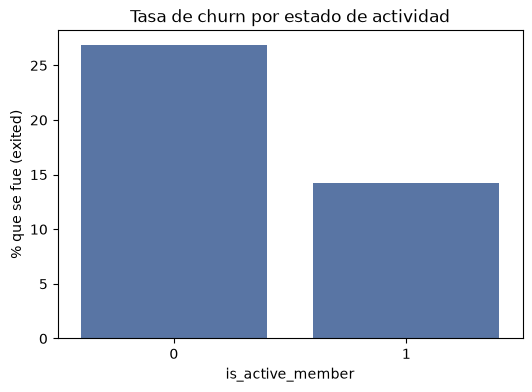

In [26]:
tasa_por_activo = df.groupby('is_active_member')['exited'].mean() * 100

plt.figure(figsize=(6, 4))
sns.barplot(x=tasa_por_activo.index, y=tasa_por_activo.values, color="#4C72B0")
plt.ylabel('% que se fue (exited)')
plt.title('Tasa de churn por estado de actividad')
plt.show()

Aca los clientes inactivos se van casi el doble que los activos, este es el más esperable de todos, tiene sentido que un cliente desconectado del banco esté más propenso a irse.

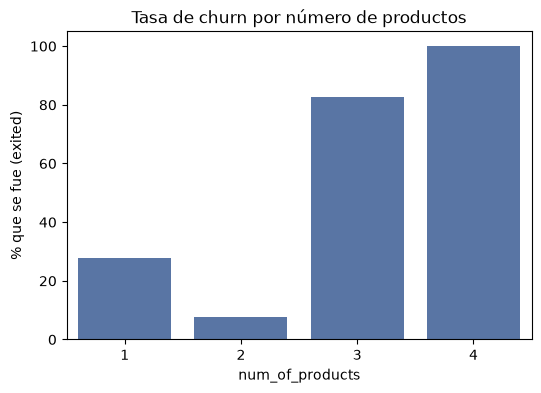

In [27]:
tasa_por_productos = df.groupby('num_of_products')['exited'].mean() * 100

plt.figure(figsize=(6, 4))
sns.barplot(x=tasa_por_productos.index, y=tasa_por_productos.values, color="#4C72B0")
plt.ylabel('% que se fue (exited)')
plt.title('Tasa de churn por número de productos')
plt.show()

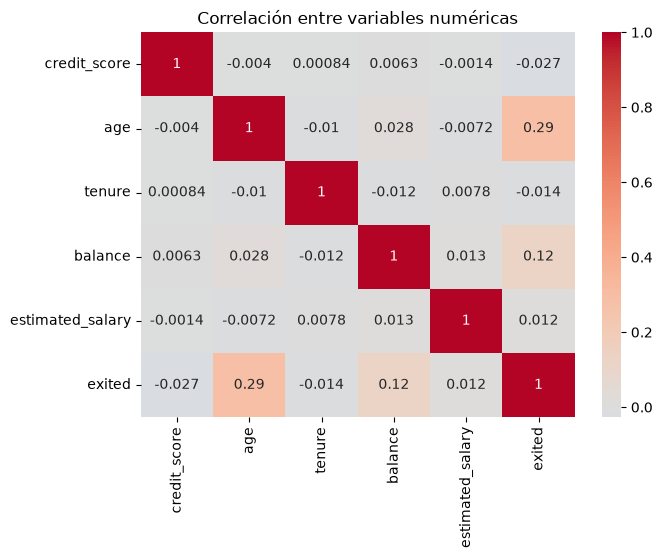

In [28]:
corr = df[['credit_score', 'age', 'tenure', 'balance', 'estimated_salary', 'exited']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlación entre variables numéricas')
plt.show()

Ahora vamos a ver histogramas y asimetria

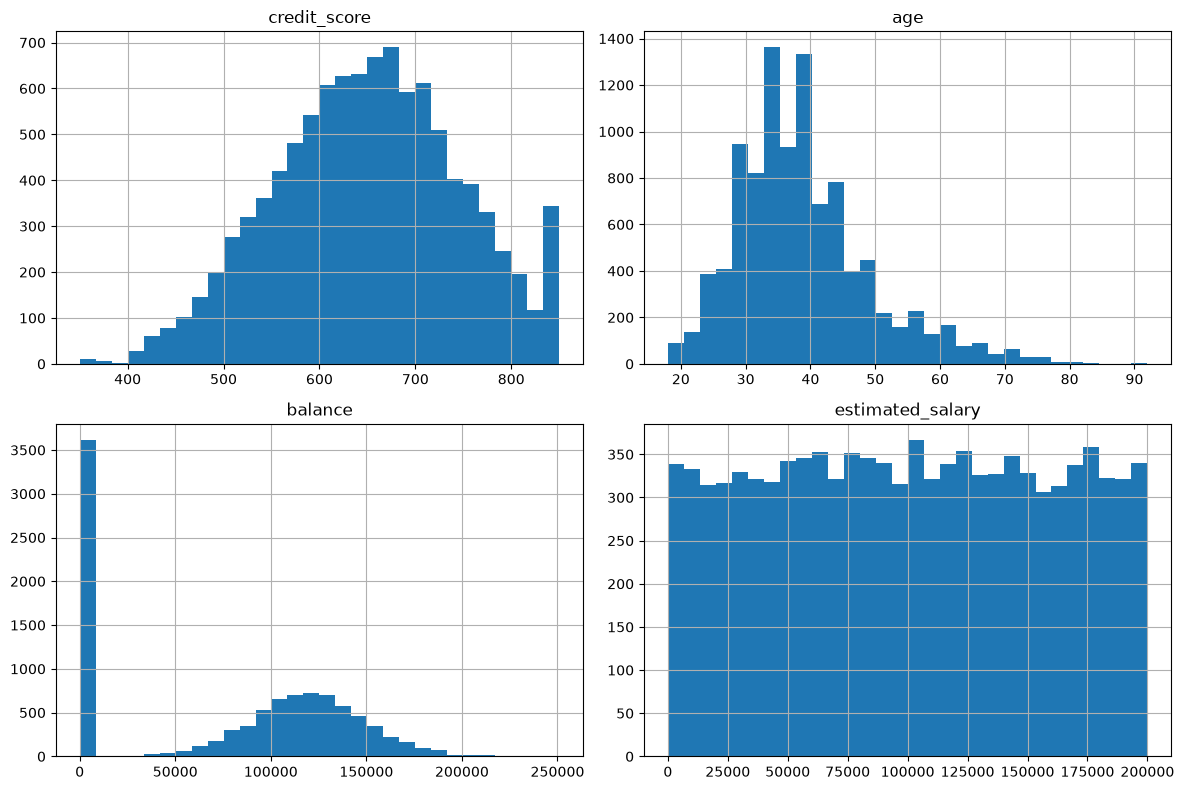

Asimetría de cada variable:
credit_score       -0.07
age                 1.01
balance            -0.14
estimated_salary    0.00
dtype: float64


In [29]:
numericas = ['credit_score', 'age', 'balance', 'estimated_salary']

df[numericas].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

print("Asimetría de cada variable:")
print(df[numericas].skew().round(2))

In [30]:
#generamos una variable derivada 
df['tiene_saldo'] = (df['balance'] > 0).astype(int)

print(df['tiene_saldo'].value_counts())
print()
print("Tasa de churn según si tiene saldo:")
print((df.groupby('tiene_saldo')['exited'].mean() * 100).round(2))

tiene_saldo
1    6383
0    3617
Name: count, dtype: int64

Tasa de churn según si tiene saldo:
tiene_saldo
0    13.82
1    24.08
Name: exited, dtype: float64


rango_edad
18-30    1968
31-40    4451
41-50    2320
51-60     797
60+       464
Name: count, dtype: int64


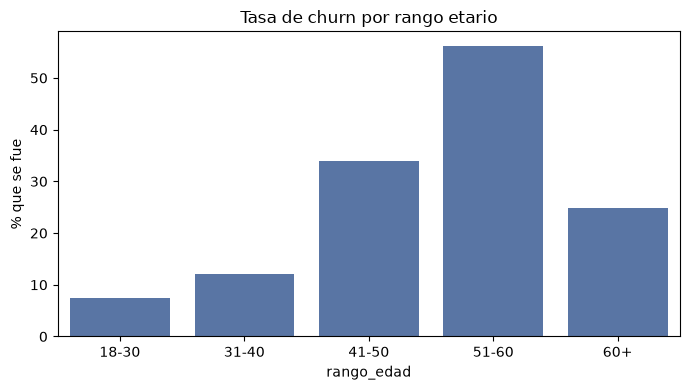

In [31]:
df['rango_edad'] = pd.cut(
    df['age'],
    bins=[18, 30, 40, 50, 60, 95],
    labels=['18-30', '31-40', '41-50', '51-60', '60+'],
    include_lowest=True
)

print(df['rango_edad'].value_counts().sort_index())

# Tasa de churn por rango etario
tasa_edad = df.groupby('rango_edad', observed=True)['exited'].mean() * 100

plt.figure(figsize=(7, 4))
sns.barplot(x=tasa_edad.index, y=tasa_edad.values, color="#4C72B0")
plt.ylabel('% que se fue')
plt.title('Tasa de churn por rango etario')
plt.tight_layout()
plt.show()

In [32]:
#ahora vamos a agrupar NumOfProducts
df['productos_agrupados'] = np.where(
    df['num_of_products'] >= 3,
    '3 o mas',
    df['num_of_products'].astype(str)
)

print(df['productos_agrupados'].value_counts().sort_index())

productos_agrupados
1          5084
2          4590
3 o mas     326
Name: count, dtype: int64


In [151]:
#validamos que no tengamos valores faltantes en las nuevas variables que generamos
nuevas = ['tiene_saldo', 'rango_edad', 'productos_agrupados']

print("Faltantes en las variables nuevas:")
print(df[nuevas].isna().sum())
print()
print("Filas totales:", len(df))

Faltantes en las variables nuevas:
tiene_saldo            0
rango_edad             0
productos_agrupados    0
dtype: int64

Filas totales: 10000


In [33]:
df_codificado = pd.get_dummies(
    df,
    columns=['geography', 'gender', 'productos_agrupados', 'rango_edad'],
    drop_first=True
)

print("Columnas antes de codificar:", df.shape[1])
print("Columnas después de codificar:", df_codificado.shape[1])
df_codificado.head()

Columnas antes de codificar: 17
Columnas después de codificar: 22


,RowNumber,CustomerId,Surname,credit_score,age,tenure,balance,num_of_products,has_cr_card,is_active_member,...,tiene_saldo,geography_Germany,geography_Spain,gender_Male,productos_agrupados_2,productos_agrupados_3 o mas,rango_edad_31-40,rango_edad_41-50,rango_edad_51-60,rango_edad_60+
0,1,15634602,Hargrave,619,42,2,0.00,1,1,1,...,0,False,False,False,False,False,False,True,False,False
1,2,15647311,Hill,608,41,1,83807.86,1,0,1,...,1,False,True,False,False,False,False,True,False,False
2,3,15619304,Onio,502,42,8,159660.80,3,1,0,...,1,False,False,False,False,True,False,True,False,False
3,4,15701354,Boni,699,39,1,0.00,2,0,0,...,0,False,False,False,True,False,True,False,False,False
4,5,15737888,Mitchell,850,43,2,125510.82,1,1,1,...,1,False,True,False,False,False,False,True,False,False


In [34]:
df_final = df_codificado.drop(columns=['RowNumber', 'CustomerId', 'Surname'])


In [35]:
print("Forma final del dataset:", df_final.shape)
print()
print("Columnas finales:")
print(df_final.columns.tolist())

Forma final del dataset: (10000, 19)

Columnas finales:
['credit_score', 'age', 'tenure', 'balance', 'num_of_products', 'has_cr_card', 'is_active_member', 'estimated_salary', 'exited', 'tiene_saldo', 'geography_Germany', 'geography_Spain', 'gender_Male', 'productos_agrupados_2', 'productos_agrupados_3 o mas', 'rango_edad_31-40', 'rango_edad_41-50', 'rango_edad_51-60', 'rango_edad_60+']


In [36]:
df_final.head()

,credit_score,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,exited,tiene_saldo,geography_Germany,geography_Spain,gender_Male,productos_agrupados_2,productos_agrupados_3 o mas,rango_edad_31-40,rango_edad_41-50,rango_edad_51-60,rango_edad_60+
0,619,42,2,0.00,1,1,1,101348.88,1,0,False,False,False,False,False,False,True,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,1,False,True,False,False,False,False,True,False,False
2,502,42,8,159660.80,3,1,0,113931.57,1,1,False,False,False,False,True,False,True,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,0,False,False,False,True,False,True,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,1,False,True,False,False,False,False,True,False,False
